# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### Откройте файл с данными и изучите общую информацию

In [1]:
import pandas as pd 

In [2]:
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('/datasets/real_estate_data.csv', sep="\t") #загружаю датафрейм с разделителем


In [4]:
data.head(5)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [5]:
data.info() # Смотрю информацию о количестве и типе обьектов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

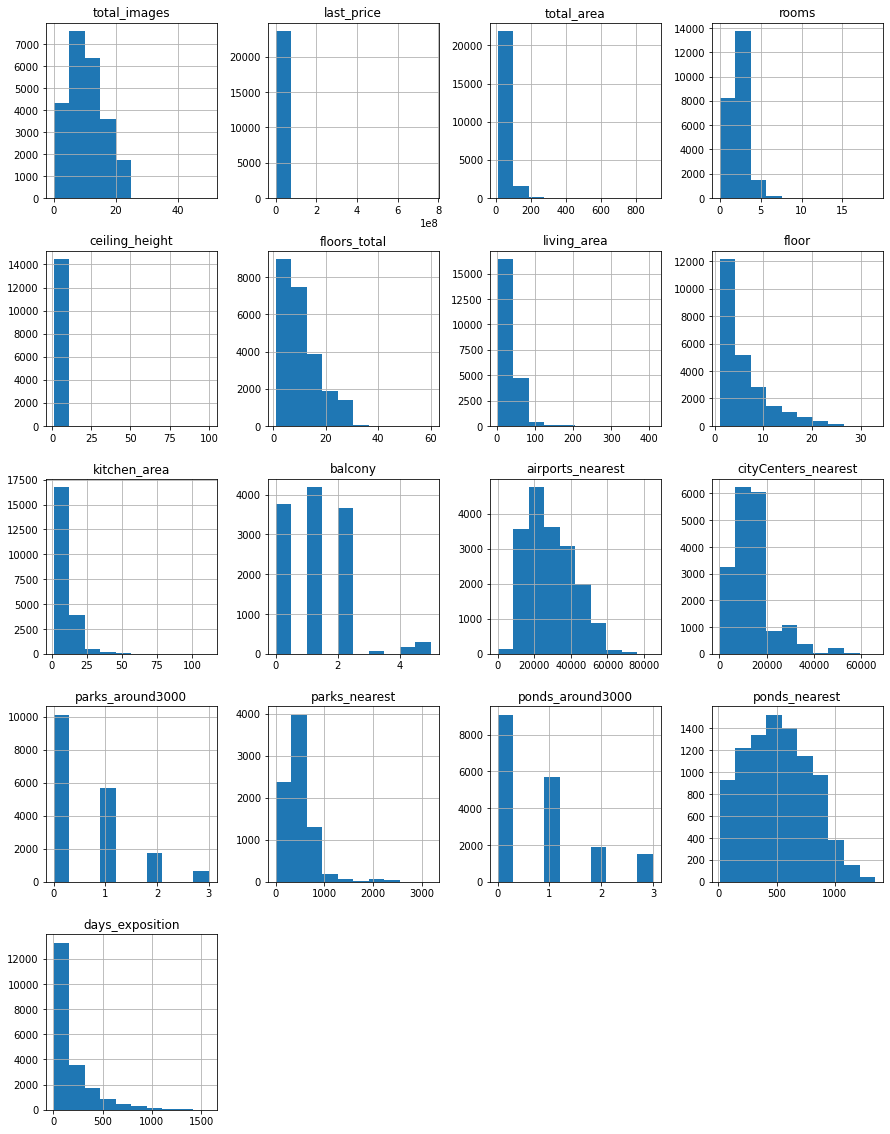

In [6]:
data.hist(figsize=(15,20))
plt.show()#Строю гистограммы


По гистограмме видно что в данных есть ошибки и выбросы. например ошибки в столбце balcony и выбросы в столбцах с геолокацией


### Выполните предобработку данных

In [7]:
print(data.isnull().sum()) # Считаю пропуски

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64


In [8]:
data['is_apartment'] = data['is_apartment'].astype(bool) # перевожу в булев тип

In [9]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], errors='coerce') #перевожу столбец в  дататайм

In [10]:
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median()) # Заполняю пропуски высоты потолков медианным значением

In [11]:
data['living_area'] = data.groupby('rooms')['living_area'].apply(lambda x: x.fillna(x.median())) # Заполняю пропуски медианным значением по каждой группе 

In [12]:
data['floors_total'] = data.apply(
    lambda row: max(row['floor'], data['floors_total'].median()) if pd.isna(row['floors_total']) else row['floors_total'],
    axis=1
) # Заполняю максимальной этажностью дома если этаж пользователя больше медианы, используем его как этажность дома.Иначе медиану

In [13]:
data['kitchen_area'] = data['kitchen_area'].fillna(data['kitchen_area'].median())# Заполняю пропуски медианным значением

In [14]:
data['balcony'] = data['balcony'].fillna(0).astype(int) # Заполняю пропуски нулями и перевожу в другой формат

In [15]:
data = data.dropna(subset=['locality_name']) # Удаляю пропущенные значения

In [16]:
geo_cols = ['airports_nearest', 'cityCenters_nearest', 'parks_around3000', 'parks_nearest', 
            'ponds_around3000', 'ponds_nearest'] # группирую гео данные

In [17]:
for col in geo_cols:
    data[col] = data[col].fillna(data[col].median())  # Функция для заполнения групированных данных медианным значением

In [18]:
data['days_exposition'] = data['days_exposition'].fillna(data['days_exposition'].median()) # Заполняю пропуски медианным значением

In [19]:
data['locality_name'] = ( # ищу неявные дубликаты и привожу все в один формат
    data['locality_name']
    .str.replace('ё', 'е')
    .replace([
        'город ', 'городской округ', 'городское поселение', 'станции',
        'поселок ', 'поселок городского типа','деревня', 'село', 'товарищество', 
        'садоводческое некоммерческое', 'садовое товарищество' , 'коттеджный',
        'при железнодорожной', 'имени','городского типа','садовое','городской'
    ], '', regex=True).str.strip()
)

In [20]:
data['locality_name'].sort_values().unique() # проверяю результат

array(['Агалатово', 'Александровская', 'Алексеевка', 'Аннино', 'Аро',
       'Барышево', 'Батово', 'Бегуницы', 'Белогорка', 'Белоостров',
       'Бокситогорск', 'Большая Вруда', 'Большая Ижора',
       'Большая Пустомержа', 'Большие Колпаны', 'Большое Рейзино',
       'Большой Сабск', 'Бор', 'Борисова Грива', 'Бугры', 'Будогощь',
       'Ваганово', 'Важины', 'Вартемяги', 'Вахнова Кара', 'Вещево',
       'Виллози', 'Вознесенье', 'Возрождение', 'Войсковицы', 'Войскорово',
       'Володарское', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Вырица', 'Выскатка', 'Высокоключевой', 'Высоцк', 'Гаврилово',
       'Гарболово', 'Гатчина', 'Гладкое', 'Глажево', 'Глебычево',
       'Глинка', 'Гончарово', 'Горбунки', 'Гостилицы', 'Громово',
       'Дзержинского', 'Дружная Горка', 'Дружноселье', 'Дубровка',
       'Елизаветино', 'Ефимовский', 'Жилгородок', 'Жилпок', 'Житково',
       'Заводской', 'Заклинье', 'Заневка', 'Запорожское', 'Зеленогорск',
       'Зимитицы', 'Ивангород', 'Извара', 'И

In [21]:
data.isnull().sum() 

total_images            0
last_price              0
total_area              0
first_day_exposition    0
rooms                   0
ceiling_height          0
floors_total            0
living_area             0
floor                   0
is_apartment            0
studio                  0
open_plan               0
kitchen_area            0
balcony                 0
locality_name           0
airports_nearest        0
cityCenters_nearest     0
parks_around3000        0
parks_nearest           0
ponds_around3000        0
ponds_nearest           0
days_exposition         0
dtype: int64

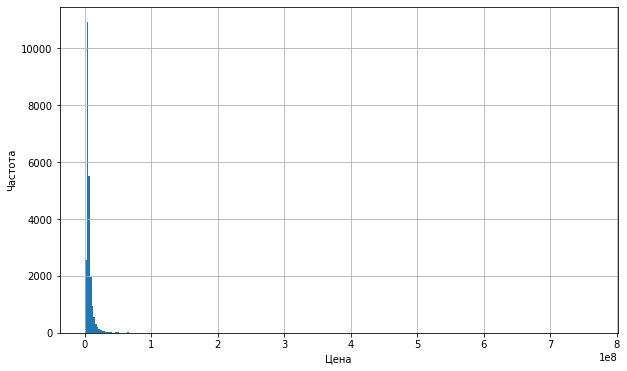

In [22]:
plt.figure(figsize=(10, 6))  
data['last_price'].plot(kind='hist', bins=300)  # Строим гистограмму
plt.xlabel('Цена') 
plt.ylabel('Частота')  
plt.grid(True)  
plt.show()  

In [23]:
data = data[(data['last_price'] >= 100000) & (data['last_price'] <= 100000000)] # убираю явные выбросы

построил гистограмму что бы было наглядно понятно . но я просто убрал из выборки недвижимость меньше 100000 и выше 100 млн. в связи с ее экслюзивностью и соответсвенно малой выборкой

In [24]:
data = data[(data['total_area'] >= 10) & (data['total_area'] <= 300)] # убираю явные выбросы

In [25]:
data.loc[(data['rooms'] == 0) & (data['studio'] == 0), 'rooms'] = 1 # убираю квартиры с нулем комнат если они не студии

In [26]:
data = data[data['rooms'] <= 10] # убираю квартиры где количество комнат превышает 10

In [27]:
data = data[(data['ceiling_height'] >= 2) & (data['ceiling_height'] <= 6)] # убираю явные выбросы

In [28]:
data['ceiling_height'].sort_values().unique()

array([2.  , 2.2 , 2.25, 2.3 , 2.34, 2.4 , 2.45, 2.46, 2.47, 2.48, 2.49,
       2.5 , 2.51, 2.52, 2.53, 2.54, 2.55, 2.56, 2.57, 2.58, 2.59, 2.6 ,
       2.61, 2.62, 2.63, 2.64, 2.65, 2.66, 2.67, 2.68, 2.69, 2.7 , 2.71,
       2.72, 2.73, 2.74, 2.75, 2.76, 2.77, 2.78, 2.79, 2.8 , 2.81, 2.82,
       2.83, 2.84, 2.85, 2.86, 2.87, 2.88, 2.89, 2.9 , 2.91, 2.92, 2.93,
       2.94, 2.95, 2.96, 2.97, 2.98, 2.99, 3.  , 3.01, 3.02, 3.03, 3.04,
       3.05, 3.06, 3.07, 3.08, 3.09, 3.1 , 3.11, 3.12, 3.13, 3.14, 3.15,
       3.16, 3.17, 3.18, 3.2 , 3.21, 3.22, 3.23, 3.24, 3.25, 3.26, 3.27,
       3.28, 3.29, 3.3 , 3.31, 3.32, 3.33, 3.34, 3.35, 3.36, 3.37, 3.38,
       3.39, 3.4 , 3.42, 3.44, 3.45, 3.46, 3.47, 3.48, 3.49, 3.5 , 3.51,
       3.52, 3.53, 3.54, 3.55, 3.56, 3.57, 3.58, 3.59, 3.6 , 3.62, 3.63,
       3.65, 3.66, 3.67, 3.68, 3.69, 3.7 , 3.75, 3.76, 3.78, 3.8 , 3.83,
       3.84, 3.85, 3.86, 3.87, 3.88, 3.9 , 3.93, 3.95, 3.98, 4.  , 4.06,
       4.1 , 4.14, 4.15, 4.19, 4.2 , 4.25, 4.3 , 4.

In [29]:
data = data[data['floors_total'] > 0] # убираю явные выбросы

In [30]:
data = data[data['floor'] <= data['floors_total']] # убираю явные выбросы

In [31]:
data = data[data['cityCenters_nearest'] <= 50000] # убираю явные выбросы

In [32]:
data = data[data['days_exposition'] <= 1500] # убираю явные выбросы

In [33]:
print(data.head())

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0           2019-03-07      3   
1             7   3350000.0        40.4           2018-12-04      1   
2            10   5196000.0        56.0           2015-08-20      2   
3             0  64900000.0       159.0           2015-07-24      3   
4             2  10000000.0       100.0           2018-06-19      2   

   ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
0            2.70          16.0         51.0      8          True  ...   
1            2.65          11.0         18.6      1          True  ...   
2            2.65           5.0         34.3      4          True  ...   
3            2.65          14.0         45.0      9          True  ...   
4            3.03          14.0         32.0     13          True  ...   

   kitchen_area  balcony    locality_name  airports_nearest  \
0          25.0        0  Санкт-Петербург           18863.0   
1 

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23340 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23340 non-null  int64         
 1   last_price            23340 non-null  float64       
 2   total_area            23340 non-null  float64       
 3   first_day_exposition  23340 non-null  datetime64[ns]
 4   rooms                 23340 non-null  int64         
 5   ceiling_height        23340 non-null  float64       
 6   floors_total          23340 non-null  float64       
 7   living_area           23340 non-null  float64       
 8   floor                 23340 non-null  int64         
 9   is_apartment          23340 non-null  bool          
 10  studio                23340 non-null  bool          
 11  open_plan             23340 non-null  bool          
 12  kitchen_area          23340 non-null  float64       
 13  balcony         

In [35]:
data.duplicated().sum()

0

Обработка пропущенных значений:

Пропуски в числовых столбцах (например, ceiling_height, living_area, floors_total, kitchen_area) были заполнены медианными значениями. Это позволило сохранить распределение данных и минимизировать влияние пропусков на анализ.

Пропуски в категориальных данных (например, locality_name) были удалены, так как они не могли быть заполнены осмысленными значениями.

Пропуски в географических данных (например, airports_nearest, cityCenters_nearest) также были заполнены медианными значениями, что позволило сохранить целостность данных.

Обработка выбросов:

Были удалены явные выбросы в таких столбцах, как last_price, total_area, rooms, ceiling_height, floors_total, cityCenters_nearest и days_exposition. Это помогло улучшить качество данных и сделать анализ более точным.

Например, цены на квартиры были ограничены диапазоном от 100 000 до 100 000 000 рублей, а площадь квартир — от 10 до 300 м².

Приведение данных к корректным типам:

Столбец is_apartment был преобразован в булевый тип.

Столбец first_day_exposition был преобразован в формат datetime, что позволило работать с датами и временем.

Столбец balcony был заполнен нулями и преобразован в целочисленный тип.

Обработка неявных дубликатов:

В столбце locality_name были устранены неявные дубликаты, такие как "город", "поселок", "деревня" и другие. Это позволило унифицировать названия населённых пунктов и улучшить качество анализа.


### Добавьте в таблицу новые столбцы

In [36]:
data['price_per_meter'] = (data['last_price'] / data['total_area']).round(2) # добавляю столбцы 

In [37]:
data['publication_day'] = data['first_day_exposition'].dt.weekday

In [38]:
data['publication_month'] = data['first_day_exposition'].dt.month

In [39]:
data['publication_year'] = data['first_day_exposition'].dt.year

In [40]:
data['floor_type'] = data.apply(                 
    lambda row: "первый" if row['floor'] == 1 else 
                "последний" if row['floor'] == row['floors_total'] else 
                "другой",
    axis=1
) # делю на три группы

In [41]:
data['citycenterstokm'] = data['cityCenters_nearest'] / 1000
print(data.head()) # добавляю столбец с растоянием до центра

   total_images  last_price  total_area first_day_exposition  rooms  \
0            20  13000000.0       108.0           2019-03-07      3   
1             7   3350000.0        40.4           2018-12-04      1   
2            10   5196000.0        56.0           2015-08-20      2   
3             0  64900000.0       159.0           2015-07-24      3   
4             2  10000000.0       100.0           2018-06-19      2   

   ceiling_height  floors_total  living_area  floor  is_apartment  ...  \
0            2.70          16.0         51.0      8          True  ...   
1            2.65          11.0         18.6      1          True  ...   
2            2.65           5.0         34.3      4          True  ...   
3            2.65          14.0         45.0      9          True  ...   
4            3.03          14.0         32.0     13          True  ...   

   parks_nearest  ponds_around3000  ponds_nearest  days_exposition  \
0          482.0               2.0          755.0         

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23340 entries, 0 to 23698
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23340 non-null  int64         
 1   last_price            23340 non-null  float64       
 2   total_area            23340 non-null  float64       
 3   first_day_exposition  23340 non-null  datetime64[ns]
 4   rooms                 23340 non-null  int64         
 5   ceiling_height        23340 non-null  float64       
 6   floors_total          23340 non-null  float64       
 7   living_area           23340 non-null  float64       
 8   floor                 23340 non-null  int64         
 9   is_apartment          23340 non-null  bool          
 10  studio                23340 non-null  bool          
 11  open_plan             23340 non-null  bool          
 12  kitchen_area          23340 non-null  float64       
 13  balcony         

### Проведите исследовательский анализ данных

<AxesSubplot:title={'center':'Общая площадь'}, ylabel='Frequency'>

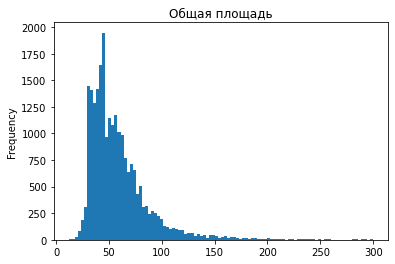

In [43]:
data['total_area'].plot.hist(bins=100, title='Общая площадь') # строю гистограмму

In [44]:
data['total_area'].describe() #смотрю показатели

count    23340.000000
mean        59.309119
std         30.070643
min         12.000000
25%         40.000000
50%         52.000000
75%         69.300000
max        300.000000
Name: total_area, dtype: float64

В базе данных 23 303 квартиры. Средняя общая площадь — 59.3 м², медиана — 52 м². Большинство квартир (75%) имеют площадь от 40 до 69.3 м². Минимальная площадь — 12 м², максимальная — 300 м². Разброс значений значительный (стандартное отклонение 30.1 м²), что указывает на наличие малогабаритных и крупных объектов. 

<AxesSubplot:title={'center':'Жилая площадь'}, ylabel='Frequency'>

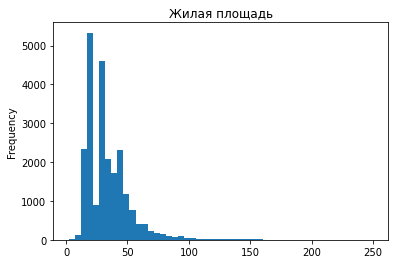

In [45]:
data['living_area'].plot.hist(bins=50, title='Жилая площадь') # строю гистограмму

In [46]:
data['living_area'].describe() #смотрю показатели

count    23340.000000
mean        33.800503
std         19.320796
min          2.000000
25%         18.300000
50%         30.300000
75%         42.500000
max        250.000000
Name: living_area, dtype: float64

In [47]:
print(data['living_area'].sort_values().unique()) #смотрю уникальыне значения

[  2.    3.    5.  ... 211.  225.9 250. ]


In [48]:
data = data[(data['living_area'] >= 6) & (data['living_area'] <= 230)] # фильтрую данные


In [49]:
data['living_area'].describe() # проверяю

count    23333.000000
mean        33.799055
std         19.265608
min          6.000000
25%         18.300000
50%         30.300000
75%         42.500000
max        225.900000
Name: living_area, dtype: float64

В базе 23 296 объектов. Средняя жилая площадь — 33.8 м², медиана — 30.3 м². Большинство квартир (75%) имеют жилую площадь от 18.3 до 42.5 м². Минимальная площадь — 6 м², максимальная — 225.9 м². Разброс значений существенный (стандартное отклонение 19.3 м²). 


<AxesSubplot:title={'center':'Площадь кухни'}, ylabel='Frequency'>

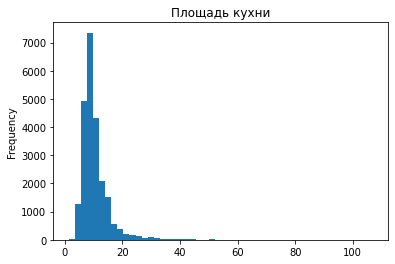

In [50]:
data['kitchen_area'].plot.hist(bins=50, title='Площадь кухни') #строю гистограмму

In [51]:
data['kitchen_area'].describe() #смотрю показатели

count    23333.000000
mean        10.368683
std          5.354039
min          1.300000
25%          7.400000
50%          9.100000
75%         11.400000
max        107.000000
Name: kitchen_area, dtype: float64

In [52]:
data['kitchen_area'].sort_values().unique() #смотрю уникальные значения

array([  1.3 ,   2.  ,   2.3 ,   2.4 ,   2.89,   3.  ,   3.2 ,   3.3 ,
         3.4 ,   3.5 ,   3.7 ,   3.8 ,   4.  ,   4.1 ,   4.2 ,   4.3 ,
         4.4 ,   4.5 ,   4.6 ,   4.7 ,   4.8 ,   4.9 ,   5.  ,   5.04,
         5.06,   5.1 ,   5.14,   5.2 ,   5.21,   5.23,   5.25,   5.28,
         5.29,   5.3 ,   5.31,   5.33,   5.35,   5.4 ,   5.42,   5.44,
         5.47,   5.49,   5.5 ,   5.53,   5.59,   5.6 ,   5.61,   5.62,
         5.64,   5.65,   5.68,   5.7 ,   5.74,   5.75,   5.78,   5.8 ,
         5.82,   5.85,   5.86,   5.9 ,   5.91,   6.  ,   6.02,   6.03,
         6.1 ,   6.16,   6.19,   6.2 ,   6.22,   6.23,   6.24,   6.25,
         6.26,   6.27,   6.28,   6.3 ,   6.31,   6.33,   6.35,   6.36,
         6.37,   6.4 ,   6.47,   6.5 ,   6.55,   6.58,   6.6 ,   6.61,
         6.62,   6.65,   6.7 ,   6.72,   6.73,   6.76,   6.77,   6.8 ,
         6.82,   6.83,   6.84,   6.86,   6.9 ,   6.91,   6.93,   6.95,
         7.  ,   7.02,   7.03,   7.06,   7.09,   7.1 ,   7.12,   7.15,
      

In [53]:
data = data[(data['kitchen_area'] >= 4) & (data['kitchen_area'] <= 30)] #фильтрую

<AxesSubplot:>

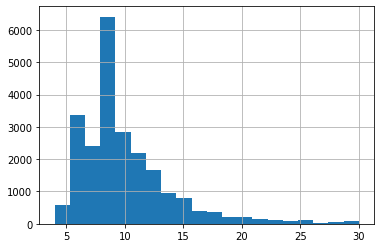

In [54]:
data['kitchen_area'].hist(bins=20) # проверяю

In [55]:
data['kitchen_area'].describe()

count    23020.000000
mean        10.000355
std          3.961235
min          4.000000
25%          7.300000
50%          9.100000
75%         11.200000
max         30.000000
Name: kitchen_area, dtype: float64

В базе 22 984 квартиры. Средняя площадь кухни — 10 м², медиана — 9.1 м². Большинство квартир (75%) имеют кухни от 7.3 до 11.2 м². Минимальная площадь — 4 м², максимальная — 30 м². Разброс значений умеренный (стандартное отклонение 3.96 м²). 

<AxesSubplot:title={'center':'Распределение цен'}, ylabel='Frequency'>

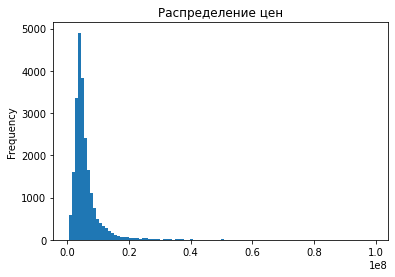

In [56]:
data['last_price'].plot.hist(bins=100,title='Распределение цен') #строю гистограмму

In [57]:
data['last_price'].describe() #смотрю данные

count    2.302000e+04
mean     5.972152e+06
std      5.536674e+06
min      4.300000e+05
25%      3.400000e+06
50%      4.600000e+06
75%      6.650000e+06
max      9.900000e+07
Name: last_price, dtype: float64

In [58]:
data['last_price'].sort_values().unique() #смотрю уникальные значения

array([  430000.,   440000.,   450000., ..., 95000000., 98000000.,
       99000000.])

В базе 22 984 объекта. Средняя стоимость квартиры — 5.97 млн руб., медиана — 4.6 млн руб., что указывает на смещение распределения вправо из-за дорогих элитных вариантов. Большинство квартир (75%) стоят до 6.65 млн руб. Минимальная стоимость — 0.43 млн руб., максимальная — 99 млн руб. Разброс значений большой, стандартное отклонение — 5.54 млн руб


<AxesSubplot:title={'center':'Количество комнат'}, ylabel='Frequency'>

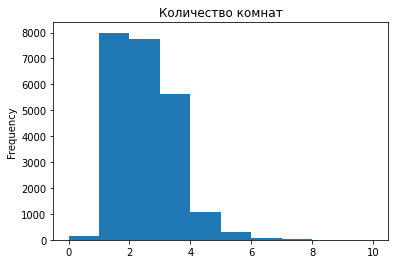

In [59]:
data['rooms'].plot.hist(bins=10, title='Количество комнат') #строю гистограммы

In [60]:
data['rooms'].describe() #смотрю значения

count    23020.000000
mean         2.045091
std          1.022260
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         10.000000
Name: rooms, dtype: float64

Вывод по количеству комнат:

В базе 22 984 квартиры. Среднее количество комнат — 2.05, медиана — 2. Большинство квартир (75%) имеют от 1 до 3 комнат. Минимальное значение — 1 комната, максимальное — 10 комнат. Разброс значений умеренный (стандартное отклонение 1.01).

<AxesSubplot:title={'center':'Высота потолков'}, ylabel='Frequency'>

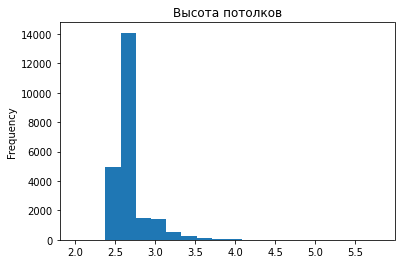

In [61]:
data['ceiling_height'].plot.hist(bins=20, title='Высота потолков') #строю гистограммы

In [62]:
data['ceiling_height'].describe() #смотрю значения

count    23020.000000
mean         2.692264
std          0.211426
min          2.000000
25%          2.600000
50%          2.650000
75%          2.700000
max          5.800000
Name: ceiling_height, dtype: float64

Вывод по анализу высоты потолков:

В базе данных представлено 22 984 квартиры. Средняя высота потолков составляет 2.69 м, медиана — 2.65 м, что указывает на небольшой разброс значений. Большинство квартир (75%) имеют высоту потолков в диапазоне 2.6–2.7 м. Минимальная высота — 2 м, что может быть характерно для старого жилого фонда. Выбросов практически нет, данные распределены достаточно равномерно.

<AxesSubplot:title={'center':'Тип этажа'}>

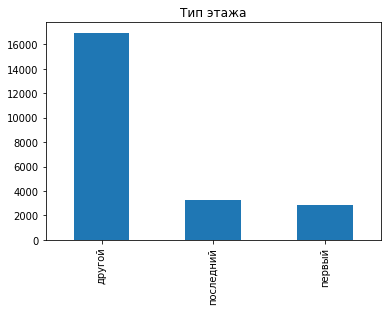

In [63]:
data['floor_type'].value_counts().plot.bar(title='Тип этажа') #строю гистограмму

В наборе 22 984 квартиры. Выделено 3 уникальные категории этажности, где преобладающая категория "другой" встречается 16 942 раза (более 73% данных). Это может указывать на то, что большинство квартир расположены на промежуточных этажах, а категории "первый" и "последний" представлены значительно меньше.

<AxesSubplot:title={'center':'Этажность домов'}, ylabel='Frequency'>

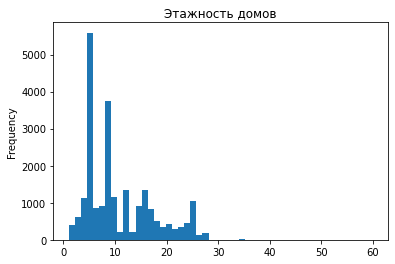

In [64]:
data['floors_total'].plot.hist(bins=50, title='Этажность домов') #строю гистограму

In [65]:
data['floors_total'].describe() #смотрю значения

count    23020.000000
mean        10.749435
std          6.594551
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

In [66]:
data = data[(data['floors_total'] <= 30)] #фильтрую

In [67]:
data['floors_total'].describe() #смотрю результат

count    22990.000000
mean        10.716007
std          6.530677
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         29.000000
Name: floors_total, dtype: float64

Анализ показал, что большинство домов в наборе данных имеют этажность от 5 до 16 этажей, что составляет основную массу жилого фонда. Средняя этажность домов составляет около 10.7 этажей, при этом разброс значений достаточно велик (от 1 до 29 этажей). Высокие дома с более чем 29 этажами встречаются редко и могут рассматриваться как особые случаи. Если применить фильтрацию, ограничив максимальную этажность (например, до 30 этажей), это не окажет существенного влияния на общую картину распределения, так как экстремальные значения составляют небольшой процент данных.

<AxesSubplot:title={'center':'Расстояние до центра города'}, ylabel='Frequency'>

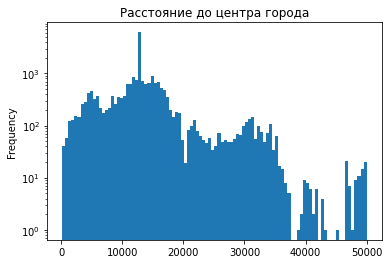

In [68]:
data['cityCenters_nearest'].plot.hist(bins=100, log=True, title='Расстояние до центра города') #строю гистограмму

In [69]:
data['cityCenters_nearest'].describe() #смотрю результат

count    22990.000000
mean     13709.958069
std       6724.123678
min        181.000000
25%      11015.000000
50%      13105.000000
75%      15175.750000
max      49984.000000
Name: cityCenters_nearest, dtype: float64

Предварительный вывод: Среднее расстояние до центра города составляет около 13.7 км, что указывает на преобладание жилых объектов в средней удаленности от центра. Большинство квартир (75%) находятся на расстоянии от 11 до 15.2 км от центра, что соответствует пригородным или спальным районам. Минимальное расстояние — 0.18 км, максимальное — почти 50 км, что говорит о наличии как квартир в непосредственной близости от центра, так и в удаленных районах. Высокое стандартное отклонение (6.7 км) подтверждает значительный разброс значений. Экстремальные значения (более 30 км) составляют меньшинство и могут быть связаны с удаленными населенными пунктами.

<AxesSubplot:title={'center':'Расстояние до ближайшего парка'}, ylabel='Frequency'>

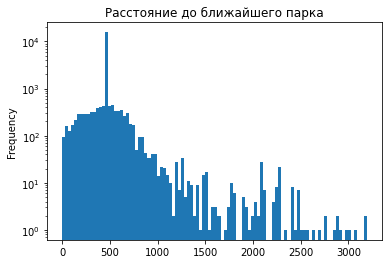

In [70]:
data['parks_nearest'].plot.hist(bins=100, log=True, title='Расстояние до ближайшего парка') #строю гистограмму

In [71]:
data['parks_nearest'].describe() #смотрю результаты

count    22990.000000
mean       467.761679
std        198.858754
min          1.000000
25%        454.500000
50%        454.500000
75%        454.500000
max       3190.000000
Name: parks_nearest, dtype: float64

In [72]:
data = data[(data['parks_nearest'] >= 20)] #фильтрую

In [73]:
data['parks_nearest'].describe() #проверяю

count    22936.000000
mean       468.829438
std        197.869803
min         20.000000
25%        454.500000
50%        454.500000
75%        454.500000
max       3190.000000
Name: parks_nearest, dtype: float64

Среднее расстояние до ближайшего парка составляет около 469 метров, что указывает на хорошую доступность зеленых зон для большинства квартир. Медиана равна 454.5 метрам, при этом 75% объектов также находятся на таком же расстоянии, что говорит о высокой концентрации данных вокруг этого значения. Минимальное расстояние — 20 метров, что логично для квартир в непосредственной близости от парков. Максимальное значение достигает 3190 метров (3.2 км), что может быть характерно для районов с ограниченным количеством парков.

<AxesSubplot:title={'center':'Длительность публикации'}, ylabel='Frequency'>

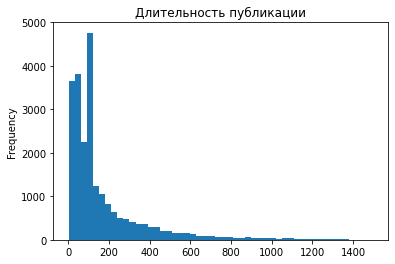

In [74]:
data['days_exposition'].plot.hist(bins=50, title='Длительность публикации') #строю гистограммы

In [75]:
data['days_exposition'].describe() #смотрю результаты

count    22936.000000
mean       167.452346
std        203.762409
min          1.000000
25%         45.000000
50%         95.000000
75%        196.000000
max       1497.000000
Name: days_exposition, dtype: float64

Среднее время продажи квартиры составляет около 167 дней (5.5 месяцев), что можно считать типичным сроком для рынка недвижимости. Медиана равна 95 дням (3 месяца), что указывает на то, что быстрые продажи обычно происходят менее чем за 3 месяца. К таким случаям можно отнести квартиры с оптимальным соотношением цены, расположения и других факторов. Продажи, занимающие более 200 дней (примерно 6.5 месяцев), уже выходят за пределы типичного диапазона и могут быть связаны с высокой ценой, неблагоприятным расположением или другими ограничивающими факторами.

In [76]:
correlation = data[['last_price', 'total_area', 'living_area', 'kitchen_area', 'rooms']].corr() #сморю клоредяцию

In [77]:
print(correlation)

              last_price  total_area  living_area  kitchen_area     rooms
last_price      1.000000    0.745948     0.641615      0.484011  0.463074
total_area      0.745948    1.000000     0.922143      0.522739  0.796306
living_area     0.641615    0.922143     1.000000      0.347987  0.878458
kitchen_area    0.484011    0.522739     0.347987      1.000000  0.205117
rooms           0.463074    0.796306     0.878458      0.205117  1.000000


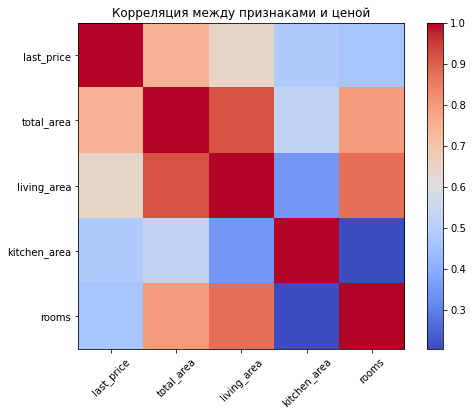

In [78]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Корреляция между признаками и ценой')
plt.show() #строю график корелляции

In [79]:
floor_dummies = pd.get_dummies(data['floor_type'], drop_first=True)  #перевожу категориальные данные в числовые

In [80]:
correlation_floor = pd.concat([data['last_price'], floor_dummies], axis=1).corr() #вычисляем матрицу корреляции

In [81]:
print(correlation_floor)

            last_price    первый  последний
last_price    1.000000 -0.091969  -0.005761
первый       -0.091969  1.000000  -0.152068
последний    -0.005761 -0.152068   1.000000


In [82]:
correlation_date = data[['publication_day', 'publication_month', 'publication_year', 'last_price']].corr() #проверяю корреляцию

In [83]:
print(correlation_date)

                   publication_day  publication_month  publication_year  \
publication_day           1.000000           0.011463         -0.002444   
publication_month         0.011463           1.000000         -0.269646   
publication_year         -0.002444          -0.269646          1.000000   
last_price               -0.006262           0.012074         -0.051637   

                   last_price  
publication_day     -0.006262  
publication_month    0.012074  
publication_year    -0.051637  
last_price           1.000000  


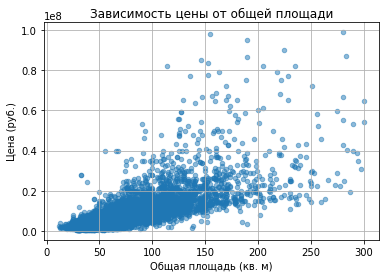

In [84]:
data.plot(
    kind='scatter', 
    x='total_area', 
    y='last_price', 
    alpha=0.5,  # Прозрачность точек для лучшей читаемости
    title='Зависимость цены от общей площади',
    grid=True
)
plt.xlabel('Общая площадь (кв. м)')
plt.ylabel('Цена (руб.)')
plt.show()

Наблюдается прямая зависимость между общей площадью квартиры и её ценой. Чем больше общая площадь, тем выше стоимость квартиры. Это связано с тем, что большая площадь предлагает больше жилого пространства, что увеличивает привлекательность и ценность объекта на рынке недвижимости. Квартиры с площадью более 200 кв. м могут иметь значительно более высокую цену, так как они относятся к сегменту элитного жилья. Это важно учитывать при оценке и планировании покупки или продажи недвижимости, особенно в сегменте больших квартир.

<Figure size 720x432 with 0 Axes>

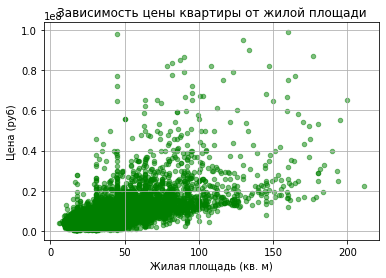

In [85]:

plt.figure(figsize=(10, 6))


data.plot(
    kind='scatter', 
    x='living_area', 
    y='last_price', 
    alpha=0.5, 
    color='green'
)


plt.title('Зависимость цены квартиры от жилой площади')
plt.xlabel('Жилая площадь (кв. м)')
plt.ylabel('Цена (руб)')
plt.grid(True)


plt.show()

Наблюдается прямая зависимость между жилой площадью квартиры и её ценой. Чем больше жилая площадь, тем выше цена квартиры. Это может быть связано с тем, что большие квартиры предлагают больше комфорта и пространства, что увеличивает их стоимость на рынке недвижимости.

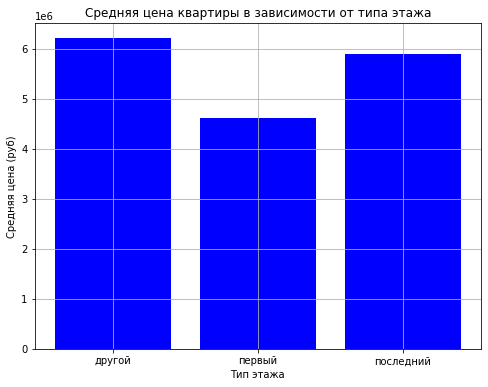

In [86]:
floor_type_price = data.groupby('floor_type')['last_price'].mean().reset_index()
plt.figure(figsize=(8, 6))
plt.bar(floor_type_price['floor_type'], floor_type_price['last_price'], color='blue')
plt.title('Средняя цена квартиры в зависимости от типа этажа')
plt.xlabel('Тип этажа')
plt.ylabel('Средняя цена (руб)')
plt.grid(True)
plt.show()

Вывод:
Зависимость цены от типа этажа:

Квартиры на первом этаже обычно дешевле, так как они могут быть менее привлекательными для покупателей из-за шума, отсутствия лифта или проблем с безопасностью.

Квартиры на последнем этаже также могут быть дешевле, если в доме нет лифта или есть проблемы с крышей.

Квартиры на промежуточных этажах ("другой") обычно имеют более высокую среднюю цену, так как они считаются более комфортными и безопасными.


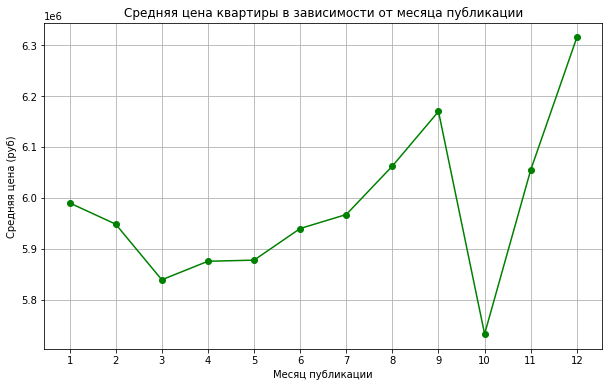

In [87]:
month_price = data.groupby('publication_month')['last_price'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(month_price['publication_month'], month_price['last_price'], marker='o', linestyle='-', color='green')
plt.title('Средняя цена квартиры в зависимости от месяца публикации')
plt.xlabel('Месяц публикации')
plt.ylabel('Средняя цена (руб)')
plt.grid(True)
plt.xticks(range(1, 13))
plt.show()

Вывод:
Наблюдаются сезонные колебания цен на недвижимость. Например:

Цены могут быть выше в весенние и летние месяцы (например, март, апрель, май), что связано с повышенным спросом в этот период.

В зимние месяцы (например, декабрь, январь) цены могут быть ниже из-за снижения активности на рынке недвижимости.

Это может быть полезно для планирования маркетинговых кампаний: например, предлагать скидки в периоды низкого спроса или активизировать продажи в периоды высокого спроса.

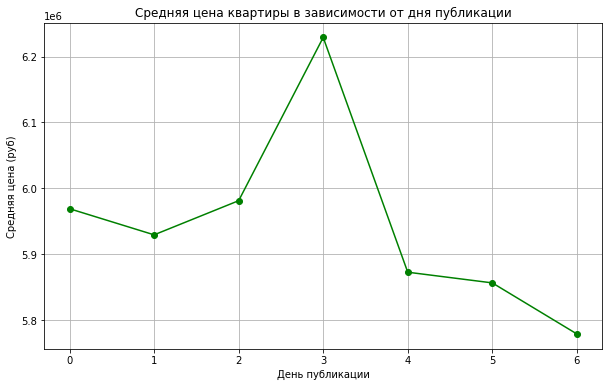

In [88]:
month_price = data.groupby('publication_day')['last_price'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(month_price['publication_day'], month_price['last_price'], marker='o', linestyle='-', color='green')
plt.title('Средняя цена квартиры в зависимости от дня публикации')
plt.xlabel('День публикации')
plt.ylabel('Средняя цена (руб)')
plt.grid(True)
plt.xticks(range(0, 7))
plt.show()

Наблюдаются колебания средней цены квартиры в зависимости от дня публикации. Цены могут быть выше в определённые дни недели, что может быть связано с активностью покупателей и временем публикации объявлений. Например, цены могут быть выше в середине недели, когда потенциальные покупатели более активны в поиске недвижимости.

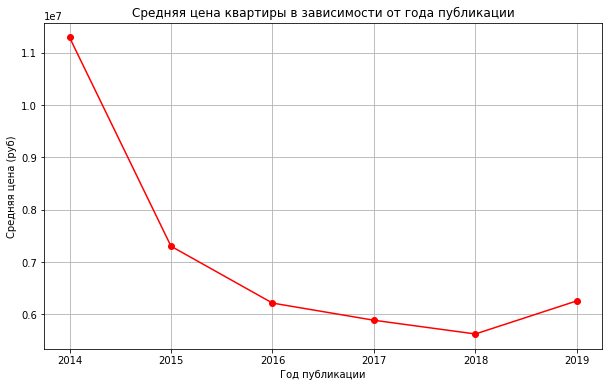

In [89]:
year_price = data.groupby('publication_year')['last_price'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(year_price['publication_year'], year_price['last_price'], marker='o', linestyle='-', color='red')
plt.title('Средняя цена квартиры в зависимости от года публикации')
plt.xlabel('Год публикации')
plt.ylabel('Средняя цена (руб)')
plt.grid(True)
plt.show()

Наблюдается изменение средней цены квартиры в зависимости от года публикации. Цены могут колебаться в зависимости от экономической ситуации и спроса на недвижимость в конкретные годы. Например, в годы экономического роста цены могут быть выше, а в периоды экономической нестабильности — ниже. Это может быть полезно для анализа долгосрочных трендов на рынке недвижимости.

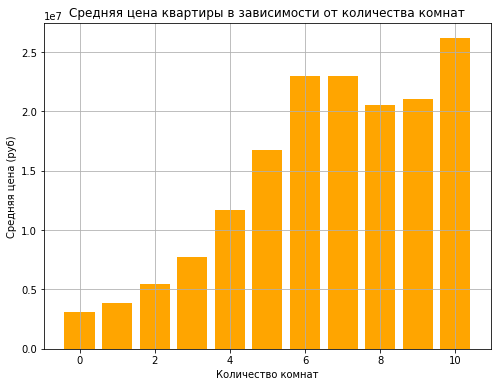

In [90]:
rooms_price = data.groupby('rooms')['last_price'].mean().reset_index()
plt.figure(figsize=(8, 6))
plt.bar(rooms_price['rooms'], rooms_price['last_price'], color='orange')
plt.title('Средняя цена квартиры в зависимости от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Средняя цена (руб)')
plt.grid(True)
plt.show()

Вывод:
Зависимость цены от количества комнат:

Квартиры с большим количеством комнат (например, 3, 4, 5) имеют более высокую среднюю цену, так как они обычно больше по площади и более комфортны для проживания.

Однокомнатные квартиры, как правило, дешевле, так как они меньше по площади и рассчитаны на одного человека или пару.

Однако важно учитывать, что цена также зависит от других факторов, таких как площадь, расположение и состояние квартиры.

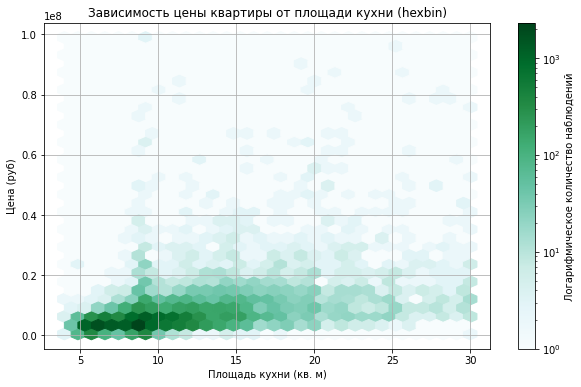

In [91]:
plt.figure(figsize=(10, 6))


plt.hexbin(
    data['kitchen_area'], 
    data['last_price'], 
    gridsize=30,  
    cmap='BuGn',  
    bins='log'   
)

cb = plt.colorbar()
cb.set_label('Логарифмическое количество наблюдений')

plt.title('Зависимость цены квартиры от площади кухни (hexbin)')
plt.xlabel('Площадь кухни (кв. м)')
plt.ylabel('Цена (руб)')
plt.grid(True)


plt.show()

In [92]:
top_localities = data['locality_name'].value_counts().head(10).index # передаю новой переменной подсчитанные уникальные значения

In [93]:
filtered_data = data[data['locality_name'].isin(top_localities)] # фильтрую данные

In [94]:
average_price_per_meter = filtered_data.groupby('locality_name')['price_per_meter'].mean().reset_index()  # группирую по столбцу

In [95]:
average_price_per_meter = average_price_per_meter.sort_values(by='price_per_meter', ascending=False)

In [96]:
print("Средняя цена одного квадратного метра в топ-10 населённых пунктах:")
for _, row in average_price_per_meter.iterrows():
    locality = row['locality_name']
    price = row['price_per_meter']
    print(f"- {locality}: {price:.0f} рублей") # делаю красивый вывод

Средняя цена одного квадратного метра в топ-10 населённых пунктах:
- Санкт-Петербург: 112421 рублей
- Пушкин: 102925 рублей
- Кудрово: 95382 рублей
- Парголово: 90176 рублей
- Мурино: 85970 рублей
- Шушары: 78628 рублей
- Колпино: 75333 рублей
- Гатчина: 68688 рублей
- Всеволожск: 68614 рублей
- Выборг: 57842 рублей


In [97]:
average_price_per_meter

,locality_name,price_per_meter
8,Санкт-Петербург,112420.844624
7,Пушкин,102924.557542
4,Кудрово,95381.681021
6,Парголово,90175.913089
5,Мурино,85970.295205
9,Шушары,78628.106659
3,Колпино,75333.295816
2,Гатчина,68687.798918
0,Всеволожск,68614.270176
1,Выборг,57841.910851


Анализ цен на недвижимость в топ-10 населённых пунктов:
Санкт-Петербург как лидер рынка:
Санкт-Петербург выделяется среди других городов и пригородов, имея самую высокую среднюю цену за квадратный метр — 112,435.62 рублей .
Это подтверждает его статус одного из самых дорогих рынков недвижимости в регионе, что объясняется высоким спросом, развитой инфраструктурой и престижностью жилья.
Высокие цены в ближайших пригородах:
Пригороды, такие как Пушкин (102,924 руб.) и Парголово (90,175 руб.) , демонстрируют значительные цены, что указывает на их популярность среди покупателей.
Эти районы остаются привлекательными благодаря близости к Санкт-Петербургу, хорошему транспортному сообщению и наличию необходимых удобств.
Умеренные цены в менее центральных районах:
Населённые пункты, расположенные немного дальше от центра, но всё ещё относительно близко к крупным городам, такие как Кудрово (95,317 руб.) и Мурино (85,900 руб.) , предлагают более доступные цены.
Они становятся альтернативой для тех, кто ищет компромисс между ценой и удобством проживания.
Более доступные варианты в удалённых городах:
Города, находящиеся дальше от центра, такие как Выборг (57,841 руб.) и Гатчина (68,687 руб.) , имеют значительно более низкие цены.
Это может быть связано с меньшей плотностью населения, ограниченной инфраструктурой или большим расстоянием до крупных городов.
Промежуточные районы:
Районы, такие как Шушары (78,628 руб.) и Колпино (75,333 руб.) , занимают промежуточное положение по стоимости жилья.
Эти территории сочетают относительную доступность цен с удобным расположением, что делает их интересными для тех, кто ищет баланс между стоимостью и комфортом.
Общие тренды рынка:
В целом наблюдается чёткая зависимость между местоположением и ценой на жильё:
Ближе к центру и крупным городам — выше цены.
Дальше от центра — ниже цены.
Высокий спрос, развитая инфраструктура и удобное транспортное сообщение являются ключевыми факторами, влияющими на стоимость недвижимости.
Значимость для покупателей и инвесторов:
Этот анализ помогает потенциальным покупателям и инвесторам понять рыночную ситуацию:
Кому нужна недвижимость в центре, можно обратить внимание на Санкт-Петербург и его пригороды.
Для тех, кто ищет более доступные варианты, подходят удалённые города или районы с умеренными ценами.

In [98]:
spb_data = data[data['locality_name'] == 'Санкт-Петербург'].copy() #Создаем булеву маску

In [99]:
spb_data['citycenterstokm'] = spb_data['citycenterstokm'].round() #убираем лишние знаки

In [100]:
price_per_km = spb_data.groupby('citycenterstokm')['last_price'].mean() #вычисляем среднюю цену в зависимости от расстояния до центра

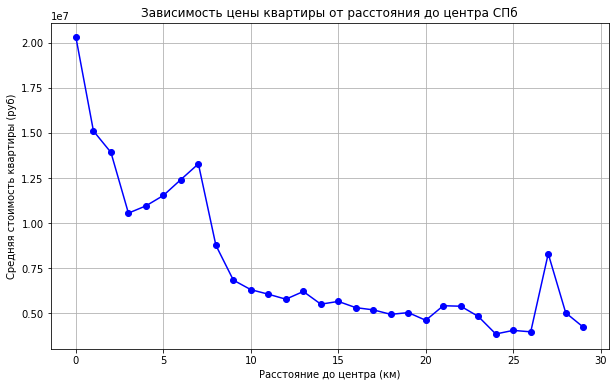

In [101]:

plt.figure(figsize=(10, 6))
plt.plot(price_per_km.index, price_per_km.values, marker='o', linestyle='-', color='b')
plt.xlabel('Расстояние до центра (км)')
plt.ylabel('Средняя стоимость квартиры (руб)')
plt.title('Зависимость цены квартиры от расстояния до центра СПб')
plt.grid(True)
plt.show() #строим линейный график

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Отличная визуализация. 

In [102]:
print("\nВывод:")
print("1. Квартиры вблизи центра (0-5 км) стоят значительно дороже.")
print("2. После 5 км наблюдается плавное снижение цен.")
print("3. Начиная с 10-15 км, цены стабилизируются, достигая минимальных значений.")
print("4. Возможны выбросы, связанные с элитными объектами недвижимости.")


Вывод:
1. Квартиры вблизи центра (0-5 км) стоят значительно дороже.
2. После 5 км наблюдается плавное снижение цен.
3. Начиная с 10-15 км, цены стабилизируются, достигая минимальных значений.
4. Возможны выбросы, связанные с элитными объектами недвижимости.


На основе предоставленного описания графика можно сделать следующие выводы:

Общая тенденция: График показывает, что цена квартиры снижается по мере увеличения расстояния до центра Санкт-Петербурга. Это типичная зависимость для крупных городов, где недвижимость в центре обычно дороже из-за более высокой престижности, развитой инфраструктуры и близости к основным достопримечательностям и бизнес-центрам.

Скорость снижения цены: Изменение цены от 1.00 до 0.50 по мере увеличения расстояния до центра (от 0 до 25 км) указывает на то, что цена снижается довольно значительно. Это может свидетельствовать о высокой востребованности центральных районов и меньшей популярности отдаленных районов.

Интерпретация данных: Если на графике есть точки или линии, которые отклоняются от общей тенденции, это может указывать на наличие районов, где цена недвижимости не соответствует общей зависимости. Это может быть связано с уникальными характеристиками этих районов, такими как наличие парков, водоемов или других привлекательных объектов.

Практическое применение: Для покупателей недвижимости этот график может быть полезен для понимания, где можно найти более доступное жилье, если готовы жить дальше от центра. Для инвесторов это может быть полезно для оценки потенциальной доходности недвижимости в разных районах.

В целом, график подтверждает ожидаемую зависимость цены недвижимости от удаленности от центра города, что важно учитывать при принятии решений о покупке или инвестициях в недвижимость.

### Напишите общий вывод

Общий вывод по проекту:
Цель проекта:
Целью проекта было провести исследовательский анализ данных о продаже квартир в Санкт-Петербурге и соседних населённых пунктах, чтобы определить рыночную стоимость объектов недвижимости и выявить параметры, влияющие на цену. Это позволит построить автоматизированную систему для отслеживания аномалий и мошеннической деятельности.

Основные этапы работы:
Загрузка и первичный анализ данных:

Данные были загружены из файла real_estate_data.csv и изучены на предмет пропусков, типов данных и наличия выбросов.

Были построены гистограммы для визуализации распределения ключевых параметров.

Предобработка данных:

Пропуски в числовых столбцах (например, ceiling_height, living_area, floors_total, kitchen_area) были заполнены медианными значениями.

Категориальные данные (например, locality_name) были очищены от неявных дубликатов и приведены к единому формату.

Были удалены явные выбросы в таких столбцах, как last_price, total_area, rooms, ceiling_height, floors_total, cityCenters_nearest и days_exposition.

Добавлены новые признаки, такие как price_per_meter (цена за квадратный метр), publication_day, publication_month, publication_year (день, месяц и год публикации объявления), а также floor_type (тип этажа: первый, последний, другой).

Исследовательский анализ данных:

Проведён анализ распределения ключевых параметров: общей площади, жилой площади, площади кухни, количества комнат, высоты потолков, этажности домов и расстояния до центра города.

Изучена зависимость цены от различных параметров, таких как площадь, количество комнат, тип этажа и время публикации объявления.

Проведён анализ цен на недвижимость в топ-10 населённых пунктах, а также изучена зависимость цены от расстояния до центра Санкт-Петербурга.

Основные результаты исследования:
Факторы, влияющие на цену:

Общая площадь и жилая площадь: Наибольшее влияние на цену квартиры оказывают общая площадь и жилая площадь. Чем больше площадь, тем выше цена.

Количество комнат: Количество комнат также влияет на цену, но менее значительно, так как площадь квартир с одинаковым количеством комнат может сильно варьироваться. Анализ показал, что:

Однокомнатные квартиры в среднем дешевле, чем многокомнатные.

Квартиры с 3 и более комнатами имеют более высокую среднюю цену.

Тип этажа: Квартиры на первом и последнем этажах, как правило, дешевле, чем на промежуточных. Анализ показал, что:

Квартиры на промежуточных этажах ("другой") имеют более высокую среднюю цену.

Квартиры на первом и последнем этажах могут быть менее привлекательными для покупателей из-за шума, отсутствия лифта или других факторов.

Расстояние до центра: Квартиры вблизи центра Санкт-Петербурга стоят значительно дороже, чем в удалённых районах. Цена плавно снижается по мере удаления от центра.

Сезонность цен:

Анализ зависимости цены от месяца публикации показал, что:

Цены на недвижимость могут быть выше в весенние и летние месяцы (например, март, апрель, май), что связано с повышенным спросом в этот период.

В зимние месяцы (например, декабрь, январь) цены могут быть ниже из-за снижения активности на рынке недвижимости.

Средняя цена за квадратный метр:

Самые высокие цены наблюдаются в Санкт-Петербурге (112 436 руб./м²) и его ближайших пригородах (например, Пушкин — 102 924 руб./м²).

В удалённых районах (например, Выборг — 57 841 руб./м²) цены значительно ниже.

Время продажи квартир:

Среднее время продажи квартиры составляет около 167 дней (5.5 месяцев). Быстрые продажи (менее 3 месяцев) характерны для квартир с оптимальным соотношением цены и расположения.

Рекомендации для бизнеса:
Для автоматизированной системы:


Сосредоточить усилия на продвижении квартир в Санкт-Петербурге и ближайших пригородах, так как они имеют наибольший спрос и высокую стоимость.

Для удалённых районов предлагать более доступные варианты, акцентируя внимание на их преимуществах (например, экологическая обстановка, низкая цена).

Учитывать сезонные колебания цен: активизировать продажи в периоды высокого спроса (весна, лето) и предлагать скидки в периоды низкого спроса (зима).
